In [1]:
import logging
import math
from typing import Callable, Dict, List, Optional, Tuple, Union

import torch
from torch import nn as nn
import torch.nn.functional as F

import warnings
warnings. filterwarnings('ignore')

import pathlib
from datetime import datetime, timedelta
from functools import partial

import numpy as np
import pandas as pd
import xarray as xr
import torch

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.ops import MLP
from torchvision.utils import _log_api_usage_once
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm

In [2]:
class PatchEmbed(nn.Module):
    """ 2D Image to Patch Embedding
    """
    output_fmt: Format
    dynamic_img_pad: torch.jit.Final[bool]

    def __init__(
            self,
            img_size: Optional[Union[int, Tuple[int, int]]] = 224,
            patch_size: int = 16,
            in_chans: int = 3,
            embed_dim: int = 768,
            norm_layer: Optional[Callable] = None,
            flatten: bool = True,
            output_fmt: Optional[str] = None,
            bias: bool = True,
            strict_img_size: bool = True,
            dynamic_img_pad: bool = False,
            device=None,
            dtype=None,
    ):
        dd = {'device': device, 'dtype': dtype}
        super().__init__()
        self.patch_size = (patch_size, patch_size)
        self.img_size, self.grid_size, self.num_patches = self._init_img_size(img_size)

        if output_fmt is not None:
            self.flatten = False
            self.output_fmt = Format(output_fmt)
        else:
            # flatten spatial dim and transpose to channels last, kept for bwd compat
            self.flatten = flatten
            # self.output_fmt = Format.NCHW
        self.strict_img_size = strict_img_size
        self.dynamic_img_pad = dynamic_img_pad

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size, bias=bias, **dd)
        self.norm = norm_layer(embed_dim, **dd) if norm_layer else nn.Identity()

    def _init_img_size(self, img_size: Union[int, Tuple[int, int]]):
        assert self.patch_size
        if img_size is None:
            return None, None, None
        img_size = (img_size, img_size)
        grid_size = tuple([s // p for s, p in zip(img_size, self.patch_size)])
        num_patches = grid_size[0] * grid_size[1]
        return img_size, grid_size, num_patches

    def set_input_size(
            self,
            img_size: Optional[Union[int, Tuple[int, int]]] = None,
            patch_size: Optional[Union[int, Tuple[int, int]]] = None,
    ):
        new_patch_size = None
        if patch_size is not None:
            new_patch_size = (patch_size, patch_size)
        if new_patch_size is not None and new_patch_size != self.patch_size:
            with torch.no_grad():
                new_proj = nn.Conv2d(
                    self.proj.in_channels,
                    self.proj.out_channels,
                    kernel_size=new_patch_size,
                    stride=new_patch_size,
                    bias=self.proj.bias is not None,
                    device=self.proj.weight.device,
                    dtype=self.proj.weight.dtype,
                )
                new_proj.weight.copy_(resample_patch_embed(self.proj.weight, new_patch_size, verbose=True))
                if self.proj.bias is not None:
                    new_proj.bias.copy_(self.proj.bias)
                self.proj = new_proj
            self.patch_size = new_patch_size
        img_size = img_size or self.img_size
        if img_size != self.img_size or new_patch_size is not None:
            self.img_size, self.grid_size, self.num_patches = self._init_img_size(img_size)

    def feat_ratio(self, as_scalar=True) -> Union[Tuple[int, int], int]:
        if as_scalar:
            return max(self.patch_size)
        else:
            return self.patch_size

    def dynamic_feat_size(self, img_size: Tuple[int, int]) -> Tuple[int, int]:
        """ Get grid (feature) size for given image size taking account of dynamic padding.
        NOTE: must be torchscript compatible so using fixed tuple indexing
        """
        if self.dynamic_img_pad:
            return math.ceil(img_size[0] / self.patch_size[0]), math.ceil(img_size[1] / self.patch_size[1])
        else:
            return img_size[0] // self.patch_size[0], img_size[1] // self.patch_size[1]

    def forward(self, x):
        B, C, H, W = x.shape
        # if self.img_size is not None:
            # if self.strict_img_size:
            #     _assert(H == self.img_size[0], f"Input height ({H}) doesn't match model ({self.img_size[0]}).")
            #     _assert(W == self.img_size[1], f"Input width ({W}) doesn't match model ({self.img_size[1]}).")
            # elif not self.dynamic_img_pad:
            #     _assert(
            #         H % self.patch_size[0] == 0,
            #         f"Input height ({H}) should be divisible by patch size ({self.patch_size[0]})."
            #     )
            #     _assert(
            #         W % self.patch_size[1] == 0,
            #         f"Input width ({W}) should be divisible by patch size ({self.patch_size[1]})."
            #     )
        if self.dynamic_img_pad:
            pad_h = (self.patch_size[0] - H % self.patch_size[0]) % self.patch_size[0]
            pad_w = (self.patch_size[1] - W % self.patch_size[1]) % self.patch_size[1]
            x = F.pad(x, (0, pad_w, 0, pad_h))
        x = self.proj(x)
        if self.flatten:
            x = x.flatten(2).transpose(1, 2)  # NCHW -> NLC
        # elif self.output_fmt != Format.NCHW:
        #     x = nchw_to(x, self.output_fmt)
        x = self.norm(x)
        return x

In [3]:
import numpy as np

import torch

# --------------------------------------------------------
# 2D sine-cosine position embedding
# References:
# Transformer: https://github.com/tensorflow/models/blob/master/official/nlp/transformer/model_utils.py
# MoCo v3: https://github.com/facebookresearch/moco-v3
# --------------------------------------------------------
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """
    grid_size: int of the grid height and width
    return:
    pos_embed: [grid_size*grid_size, embed_dim] or [1+grid_size*grid_size, embed_dim] (w/ or w/o cls_token)
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """
    embed_dim: output dimension for each position
    pos: a list of positions to be encoded: size (M,)
    out: (M, D)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

In [4]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
# --------------------------------------------------------
# References:
# timm: https://github.com/rwightman/pytorch-image-models/tree/master/timm
# DeiT: https://github.com/facebookresearch/deit
# --------------------------------------------------------

from functools import partial

import torch
import torch.nn as nn

# from timm.models.vision_transformer import PatchEmbed, Block
from torchvision.models.vision_transformer import EncoderBlock as Block

# from util.pos_embed import get_2d_sincos_pos_embed


class MaskedAutoencoderViT(LightningModule):
    """ Masked Autoencoder with VisionTransformer backbone
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=1024, depth=24, num_heads=16,
                 decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
                 mlp_ratio=4., norm_layer=nn.LayerNorm, norm_pix_loss=False):
        super().__init__()

        self.in_chans = in_chans

        # --------------------------------------------------------------------------
        # MAE encoder specifics
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)  # fixed sin-cos embedding

        self.blocks = nn.ModuleList([
            Block( num_heads, embed_dim, int(embed_dim*mlp_ratio), 0., 0., norm_layer=norm_layer)
            for i in range(depth)])
        self.norm = norm_layer(embed_dim)
        # --------------------------------------------------------------------------

        # --------------------------------------------------------------------------
        # MAE decoder specifics
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))

        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)  # fixed sin-cos embedding

        self.decoder_blocks = nn.ModuleList([
            Block( decoder_num_heads, decoder_embed_dim, int(decoder_embed_dim*mlp_ratio), 0., 0., norm_layer=norm_layer)
            for i in range(decoder_depth)])

        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True) # decoder to patch
        # --------------------------------------------------------------------------

        self.norm_pix_loss = norm_pix_loss

        self.initialize_weights()

    def initialize_weights(self):
        # initialization
        # initialize (and freeze) pos_embed by sin-cos embedding
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], int(self.patch_embed.num_patches**.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))

        # initialize patch_embed like nn.Linear (instead of nn.Conv2d)
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        # timm's trunc_normal_(std=.02) is effectively normal_(std=0.02) as cutoff is too big (2.)
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # we use xavier_uniform following official JAX ViT:
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def patchify(self, imgs):
        """
        imgs: (N, 3, H, W)
        x: (N, L, patch_size**2 *3)
        """
        p = self.patch_embed.patch_size[0]
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0

        h = w = imgs.shape[2] // p
        x = imgs.reshape(shape=(imgs.shape[0], self.in_chans, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * self.in_chans))
        return x

    def unpatchify(self, x):
        """
        x: (N, L, patch_size**2 *3)
        imgs: (N, 3, H, W)
        """
        p = self.patch_embed.patch_size[0]
        h = w = int(x.shape[1]**.5)
        assert h * w == x.shape[1]
        
        x = x.reshape(shape=(x.shape[0], h, w, p, p, self.in_chans))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], self.in_chans, h * p, h * p))
        return imgs

    def random_masking(self, x, mask_ratio):
        """
        Perform per-sample random masking by per-sample shuffling.
        Per-sample shuffling is done by argsort random noise.
        x: [N, L, D], sequence
        """
        N, L, D = x.shape  # batch, length, dim
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)  # noise in [0, 1]
        
        # sort noise for each sample
        ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # keep the first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # generate the binary mask: 0 is keep, 1 is remove
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        # unshuffle to get the binary mask
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        # embed patches
        x = self.patch_embed(x)

        # add pos embed w/o cls token
        x = x + self.pos_embed[:, 1:, :]

        # masking: length -> length * mask_ratio
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        # append cls token
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # apply Transformer blocks
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        # embed tokens
        x = self.decoder_embed(x)

        # append mask tokens to sequence
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # no cls token
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))  # unshuffle
        x = torch.cat([x[:, :1, :], x_], dim=1)  # append cls token

        # add pos embed
        x = x + self.decoder_pos_embed

        # apply Transformer blocks
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)

        # predictor projection
        x = self.decoder_pred(x)

        # remove cls token
        x = x[:, 1:, :]

        return x

    def forward_loss(self, imgs, pred, mask):
        """
        imgs: [N, 3, H, W]
        pred: [N, L, p*p*3]
        mask: [N, L], 0 is keep, 1 is remove, 
        """
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**.5

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # [N, L], mean loss per patch

        loss = (loss * mask).sum() / mask.sum()  # mean loss on removed patches
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)  # [N, L, p*p*3]
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

    def training_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log training loss
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log validation loss
        self.log(
            "val_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.forward(batch)[0]
        # log test loss
        self.log(
            "test_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters())

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": ReduceLROnPlateau(optimizer),
                "patience": 10,
                "interval": "epoch",
                "monitor": "val_loss",
                "frequency": 1,
            },
        }


def mae_vit_base_patch16_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=16, embed_dim=768, depth=12, num_heads=12,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model


def mae_vit_large_patch16_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=16, embed_dim=1024, depth=24, num_heads=16,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model


def mae_vit_huge_patch14_dec512d8b(**kwargs):
    model = MaskedAutoencoderViT(
        patch_size=14, embed_dim=1280, depth=32, num_heads=16,
        decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
        mlp_ratio=4, norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
    return model


# set recommended archs
mae_vit_base_patch16 = mae_vit_base_patch16_dec512d8b  # decoder: 512 dim, 8 blocks
mae_vit_large_patch16 = mae_vit_large_patch16_dec512d8b  # decoder: 512 dim, 8 blocks
mae_vit_huge_patch14 = mae_vit_huge_patch14_dec512d8b  # decoder: 512 dim, 8 blocks

In [5]:
model = MaskedAutoencoderViT(img_size=256, in_chans=16)

In [6]:
import pathlib
data_path = pathlib.Path("../data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))


In [7]:
class GeoDataset(Dataset):
    def __init__(self, files):
        super().__init__()
        self.files = files
    
    def __len__(self):
        return len(self.files)

    def load_image(self, idx):
        with xr.open_datatree(self.files[idx]) as dt:
            image_input = dt.geo_patch.data.fillna(0)
            image_input[:6] = image_input[:6] / 100
            image_input[6:] = image_input[6:] / 140 - 180
            image_input = np.clip(image_input, 0, 1).values.astype(np.float32)
            
        return image_input
    
    def __getitem__(self, idx):
        return self.load_image(idx)

class GeoDataloader(LightningDataModule):
    def __init__(
        self, 
        batch_size, 
        files, 
        num_workers=0, 
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Get list of files for each split
        self.train_dataset = GeoDataset(files[:int(len(files)*0.7)])
        self.val_dataset = GeoDataset(files[int(len(files)*0.75):int(len(files)*0.85)])
        self.test_dataset = GeoDataset(files[int(len(files)*0.9):])

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )

In [8]:
class LitProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = tqdm(            
            disable=True,            
        )
        return bar

# Add a logger for metrics and checkpoints
csv_logger = CSVLogger(
    save_dir='',
    name='logs'
)

In [9]:
_ = seed_everything(42)

dl = GeoDataloader(8, files)

model = MaskedAutoencoderViT(img_size=256, in_chans=16)

# Initialize the trainer
trainer = Trainer(
    max_epochs=100,
    callbacks=[LitProgressBar()],
    logger=csv_logger,
    accelerator="auto",
)

trainer.fit(model, dl)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name           | Type       | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | patch_embed    | PatchEmbed | 4.2 M  | train | 0    
1 | blocks         | ModuleList | 302 M  | train | 0    
2 | norm           | LayerNorm  | 2.0 K  | train | 0    
3 | decoder_embed  | Linear     | 524 K  | train | 0    
4 | decoder_blocks | ModuleList | 25.2 M | train | 0    
5 | decoder_norm   | LayerNorm  | 1.0 K  | train | 0    
6 | decoder_pred   | Linear     | 2.1 M  | train | 0    
  | other params   | n/a        | 396 K  | n/a   | n/a  
--------------------------------------------------------------
334 M     Trainable params
394 K     Non-trainable params
334

Epoch 19:  34%|█▋   | 89/263 [01:34<03:03,  0.95it/s, v_num=35, train_loss_step=0.00721, val_loss_step=0.00399, val_loss_epoch=0.00839, train_loss_epoch=0.00864]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [10]:
_ = model.eval()

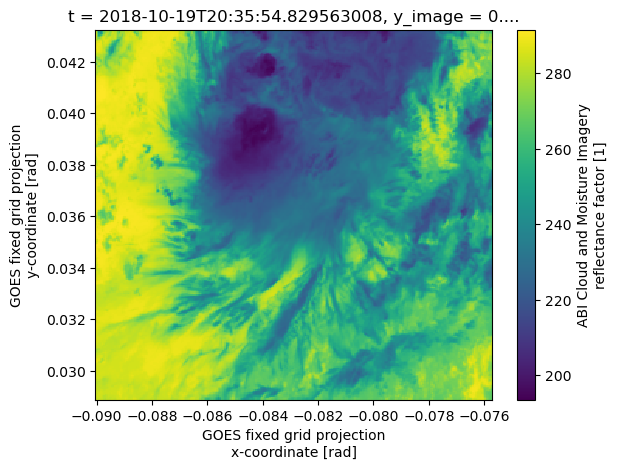

In [11]:
dt = xr.open_datatree(files[300])
image_input = dt.geo_patch.data
image_input[-3].plot()
image_input[:6] = image_input[:6] / 100
image_input[6:] = image_input[6:] / 140 - 180
image_input = np.clip(image_input, 0, 1)
image_input = torch.tensor(image_input.data[np.newaxis])

In [12]:
test = model.forward(image_input)[1]

In [13]:
test.shape

torch.Size([1, 256, 4096])

In [14]:
test = model.unpatchify(test).detach().numpy()[0]

In [15]:
test.shape

(16, 256, 256)

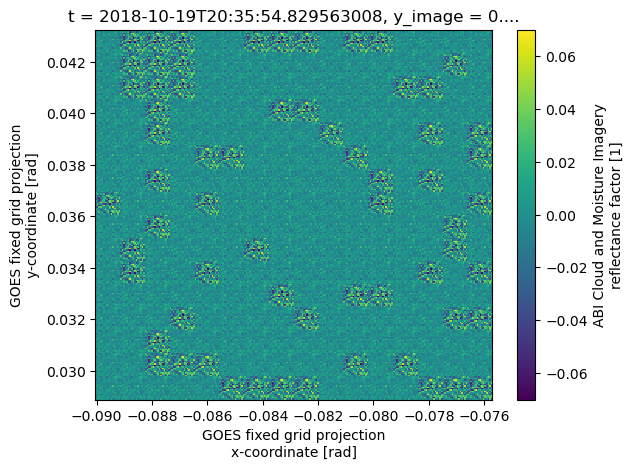

In [16]:
dt.geo_patch.data.copy(data=test)[-3].plot(cmap="viridis")